In [82]:
import duckdb
import os
import pandas
import matplotlib.pyplot as plt
import polars as pl
import pandas as pd
from lifelines import KaplanMeierFitter
from lifelines import WeibullFitter
from lifelines import WeibullAFTFitter
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
os.chdir("..")

In [3]:
con = duckdb.connect("uk_car_analyser.duckdb")

In [4]:
con.execute("""
    COPY(
        WITH last_test_prep AS(
           SELECT vehicle_id, (DATE_DIFF('day', first_use_date, test_date))/365.25 AS t, 
           IF(test_result IN ('ABA', 'F'), 1, 0) AS event,
           IF(
               test_result NOT IN ('ABA', 'F') AND test_date<'2024-12-31',
               1,
               0
            ) AS interval_censored,
           make, model, 
           fuel_type, cylinder_capacity, test_mileage,
           first_use_date AS start_date, test_date AS end_date,
           ROW_NUMBER()OVER(PARTITION BY vehicle_id ORDER BY test_date DESC, test_id DESC) AS rownum
           
           FROM read_parquet('data/mot_data_combined.parquet')
           WHERE first_use_date<test_date
           
        )
    
        SELECT * EXCLUDE(rownum) FROM last_test_prep WHERE rownum=1
    ) TO 'data/mot_last_test.parquet' (FORMAT PARQUET); 
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [69]:
df = pl.scan_parquet('data/mot_last_test.parquet').collect()

In [71]:
df = df.filter(pl.col('start_date')>=pl.lit('1900-01-01').str.to_date())
df = df.filter(pl.col('event')==1)

df = df.to_pandas()

In [72]:
# test for interval censoring
df['test_mileage'] = df['test_mileage'].replace(0,1)
df['test_mileage_upper'] = df['test_mileage'].copy()
df.loc[df['event'] == 0, 'test_mileage_upper'] = df.loc[df['event'] == 0, 'test_mileage'] + 7000

In [73]:
df['end_date'] = pd.to_datetime(df['end_date'])

In [78]:
print(df['test_mileage'].mean())

104622.42765258429


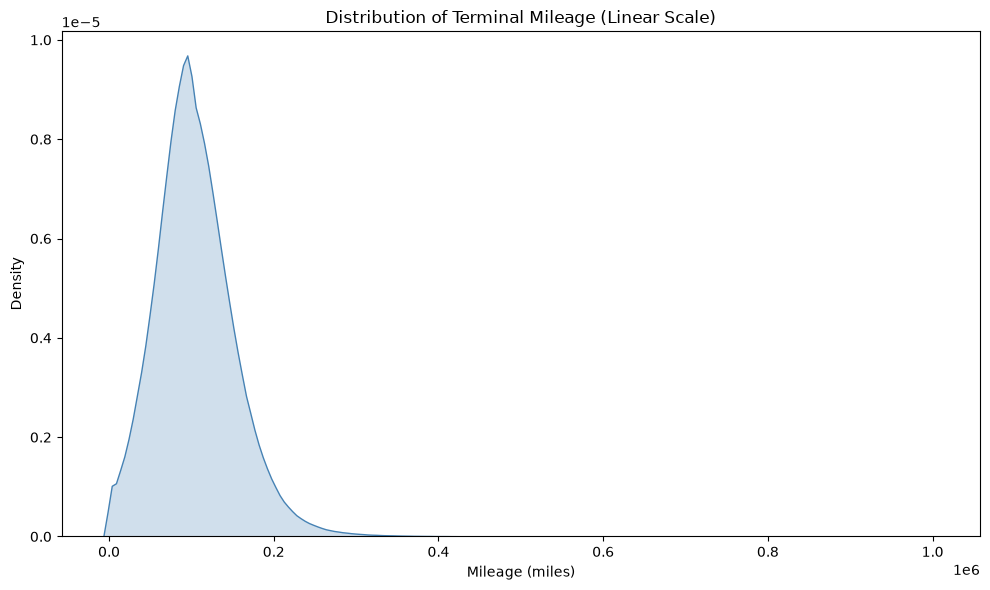

In [74]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="test_mileage", fill=True, color="steelblue")
plt.title("Distribution of Terminal Mileage (Linear Scale)")
plt.xlabel("Mileage (miles)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

In [75]:
kmf = KaplanMeierFitter()

kmf.fit(
    df['test_mileage'],
    event_observed=df['event']
)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 5.68183e+06 total observations, 0 right-censored observations>

<Axes: xlabel='timeline'>

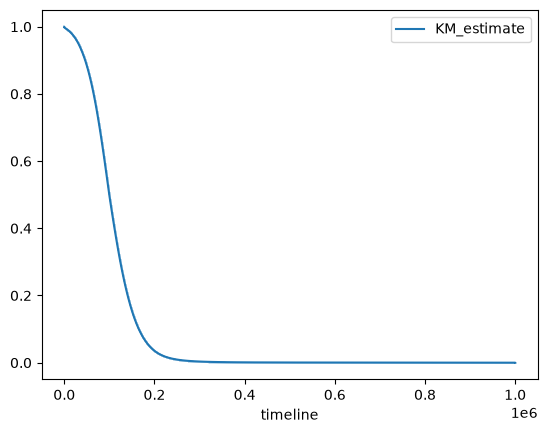

In [76]:
kmf.plot()

In [ ]:
kmf.plot()

In [77]:
print(f"Median Survival Mileage: {kmf.median_survival_time_:.0f} miles")

Median Survival Mileage: 99803 miles


In [114]:
counts = df['make'].value_counts()

# 2. Identify makes with > 5000 entries
valid_makes = counts[counts > 10000].index

# 3. Filter the dataframe
df_sample = df[df['make'].isin(valid_makes)]
df_sample = df.sample(frac=0.3, random_state=123)

In [117]:
weibull_aft = WeibullAFTFitter()

weibull_aft.fit(
    df_sample,
    duration_col = 'test_mileage',
    event_col = 'event',
    formula = 'make'
)

MemoryError: Unable to allocate 7.80 GiB for an array with shape (614, 1704548) and data type float64

In [110]:
lambda_coeffs = weibull_aft.summary.loc['lambda_']['coef']

In [111]:
sorted_coeffs = lambda_coeffs.sort_values(ascending=False)

In [112]:
sorted_coeffs.head(5)

covariate
Intercept                   11.665743
make[T.CADILLAC]             1.674216
make[T.OPTARE]               1.324036
make[T.LONDON TAXIS INT]     1.142290
make[T.CARBODIES]            1.062208
Name: coef, dtype: float64

In [113]:
sorted_coeffs.tail(5)

covariate
make[T.AIXAM]     -2.793434
make[T.KTM]       -2.897703
make[T.VMOTO]     -2.915717
make[T.M G]       -3.505929
make[T.LEXMOTO]   -5.836805
Name: coef, dtype: float64

In [15]:
con.execute("""
SELECT min(first_use_date) FROM read_parquet('data/mot_data_combined.parquet')
           WHERE first_use_date<'1960-01-01'

""").df()

,min(first_use_date)
0,1-01-01


In [116]:
del df